<a href="https://colab.research.google.com/github/hideaki-kyutech/syseng2026/blob/main/week11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== 使用画像一覧 ===


,image_id,name,hand_complexity,base_size_kbit,edge,contrast,brightness,color_var
0,0,astronaut,0.836123,88.528582,1.000000,0.565499,0.464059,0.606272
1,1,coffee,0.532175,67.252269,0.574303,0.388671,0.313682,0.420442
2,2,chelsea,0.342141,53.949875,0.520052,0.180158,0.470650,0.192413
3,3,camera,0.635230,74.466123,0.466111,0.565361,0.600057,0.565361
4,4,rocket,0.155714,40.899970,0.115079,0.138207,0.000000,0.162955
5,5,coins,0.586770,71.073896,0.782899,0.359352,0.297216,0.359352
6,6,page,0.657485,76.023955,0.946310,0.370735,1.000000,0.370735
7,7,text,0.253807,47.766466,0.497375,0.082060,0.601905,0.082060
8,8,horse,1.000000,100.000000,0.495833,1.000000,0.991218,1.000000
9,9,moon,0.000000,30.000000,0.000000,0.000000,0.441184,0.000000


=== Required Channels 教師データ ===


,name,hand_complexity,required_channels
0,astronaut,0.836123,4
1,coffee,0.532175,3
2,chelsea,0.342141,3
3,camera,0.635230,3
4,rocket,0.155714,2
5,coins,0.586770,4
6,page,0.657485,6
7,text,0.253807,4
8,horse,1.000000,3
9,moon,0.000000,1



=== コンペ結果 ===


,team,strategy,optimizer,selected_nn_arch,compute_cost,score,mean_ssim,mean_bits_kbit,mean_comm_time_sec,mean_compute_time_sec,mean_total_time_sec,violation_rate,min_ssim,max_bits_kbit
0,Team A,HAND_FI,NONE,None,14,83.245558,0.916794,43.776504,0.87553,0.028,0.90353,0.1,0.822564,100.0



=== 画像ごとの評価結果 ===


,image_id,name,hand_complexity,required_channels,predicted_channels,ssim,bits_kbit,communication_time_sec,compute_time_sec,total_time_sec,compute_cost,violation
0,0,astronaut,0.836123,4,7,0.961654,77.462509,1.549250,0.028,1.577250,14,False
1,1,coffee,0.532175,3,5,0.934630,42.032668,0.840653,0.028,0.868653,14,False
2,2,chelsea,0.342141,3,3,0.879513,20.231203,0.404624,0.028,0.432624,14,False
3,3,camera,0.635230,3,6,0.942468,55.849593,1.116992,0.028,1.144992,14,False
4,4,rocket,0.155714,2,3,0.912331,15.337489,0.306750,0.028,0.334750,14,False
5,5,coins,0.586770,4,5,0.917153,44.421185,0.888424,0.028,0.916424,14,False
6,6,page,0.657485,6,6,0.877751,57.017966,1.140359,0.028,1.168359,14,False
7,7,text,0.253807,4,3,0.822564,17.912425,0.358248,0.028,0.386248,14,True
8,8,horse,1.000000,3,8,0.999995,100.000000,2.000000,0.028,2.028000,14,False
9,9,moon,0.000000,1,2,0.919885,7.500000,0.150000,0.028,0.178000,14,False


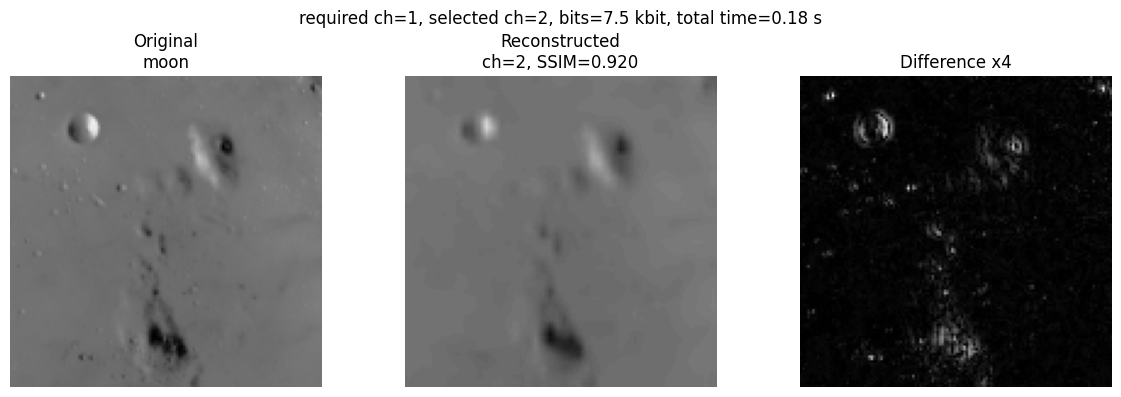

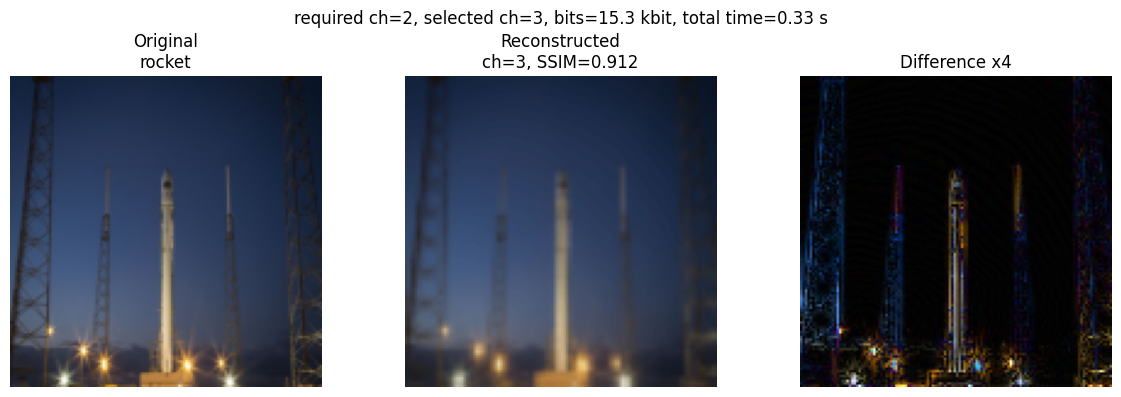

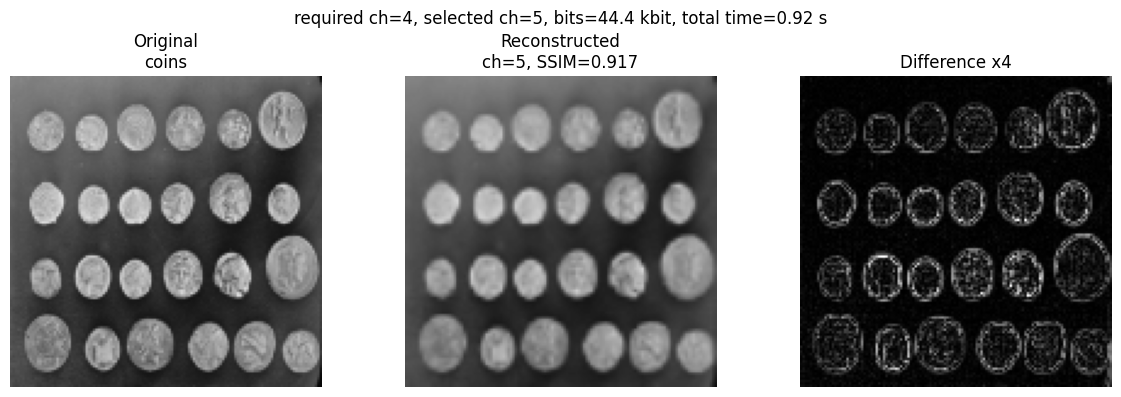

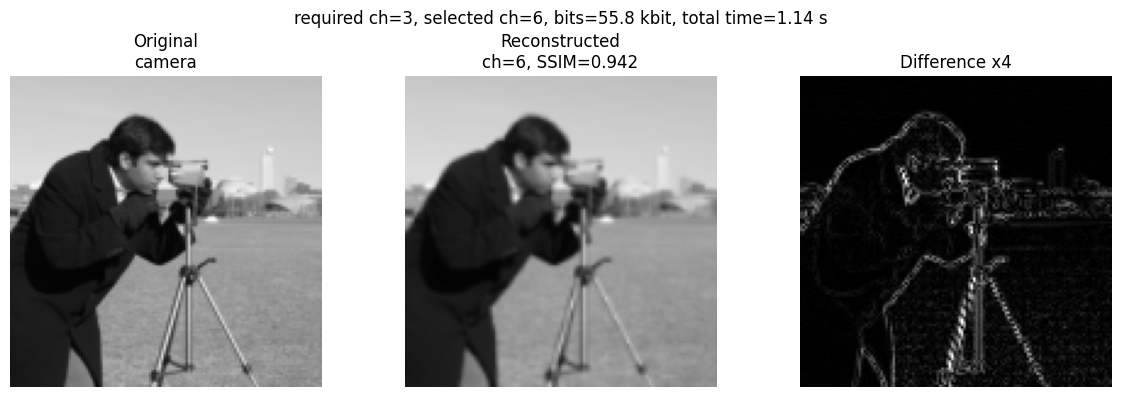

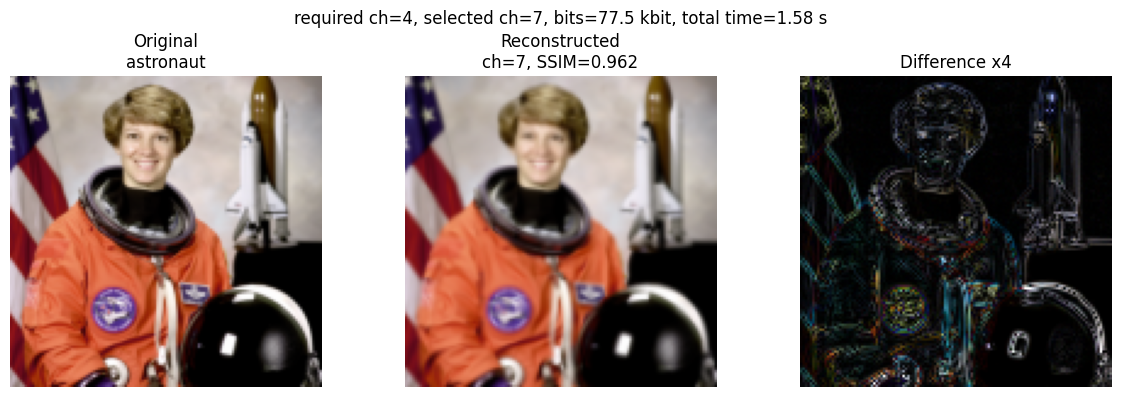

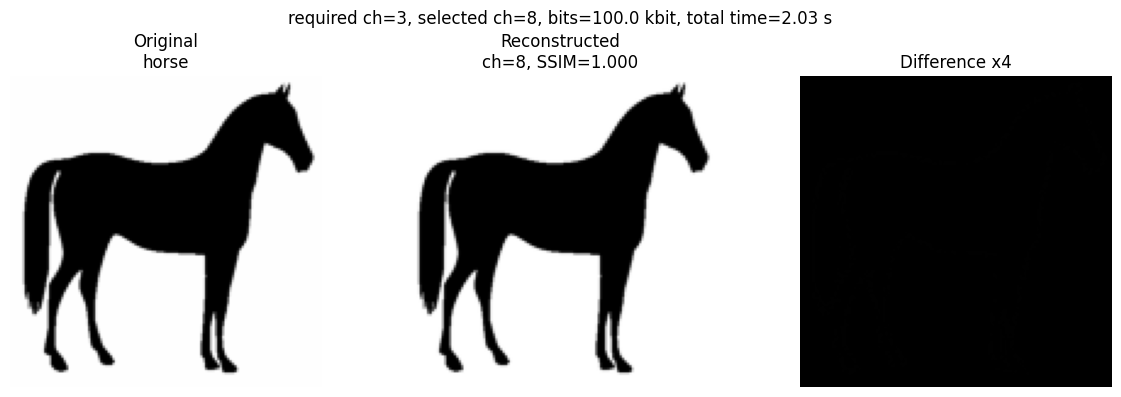

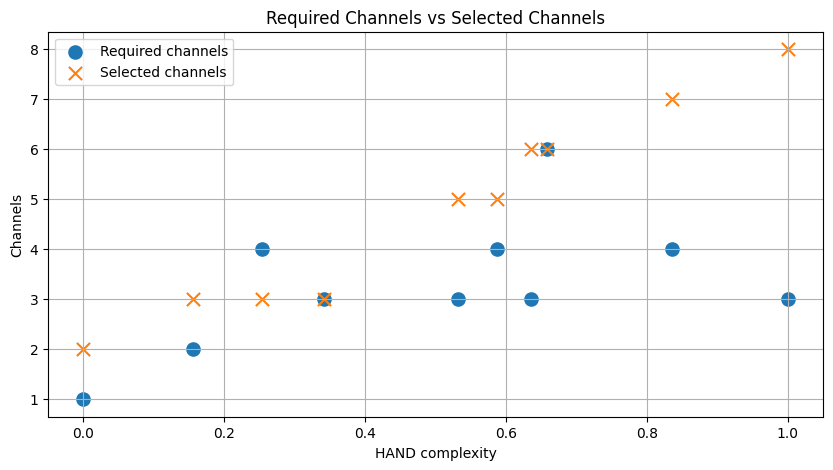

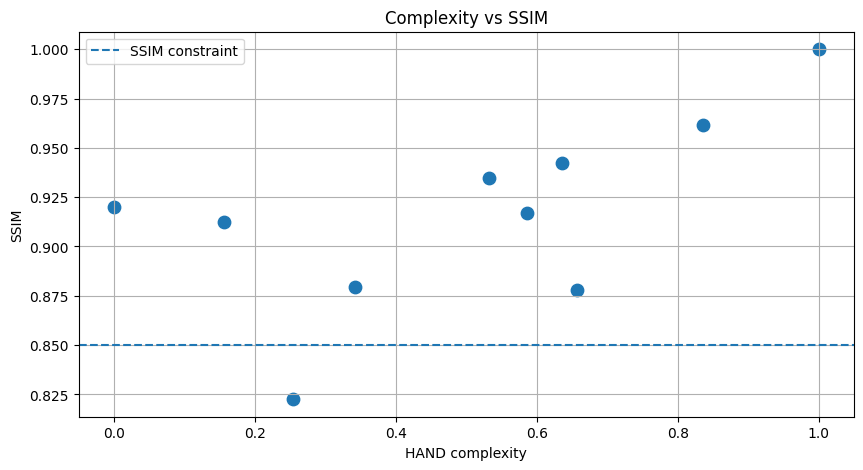

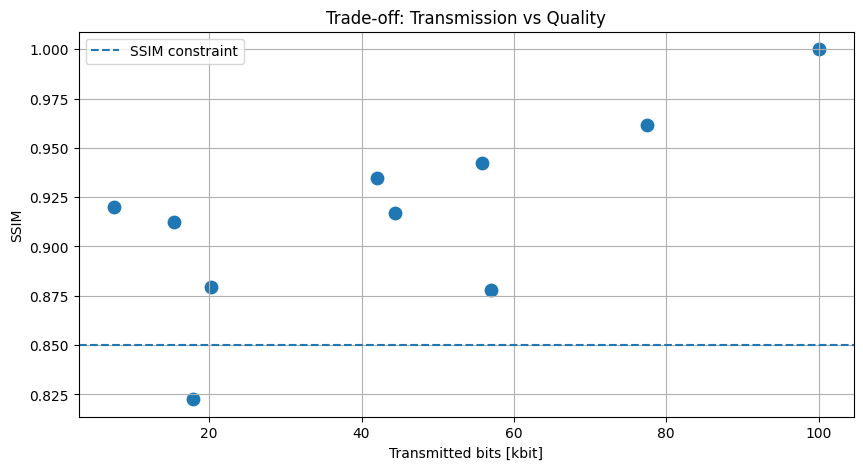

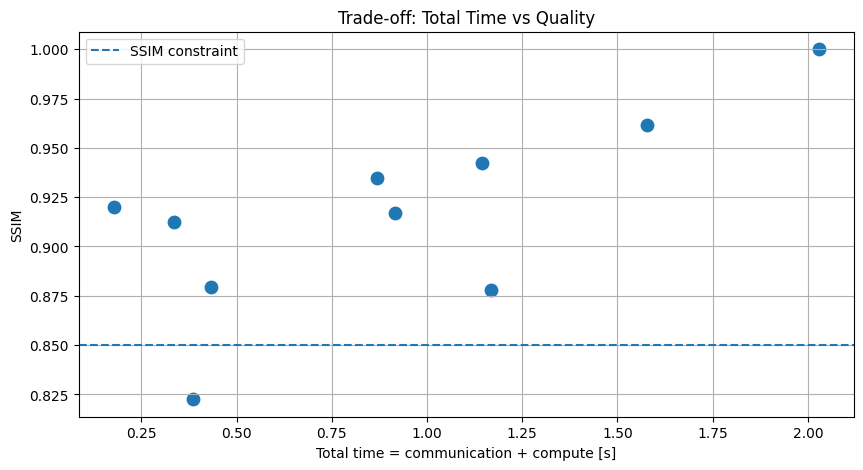

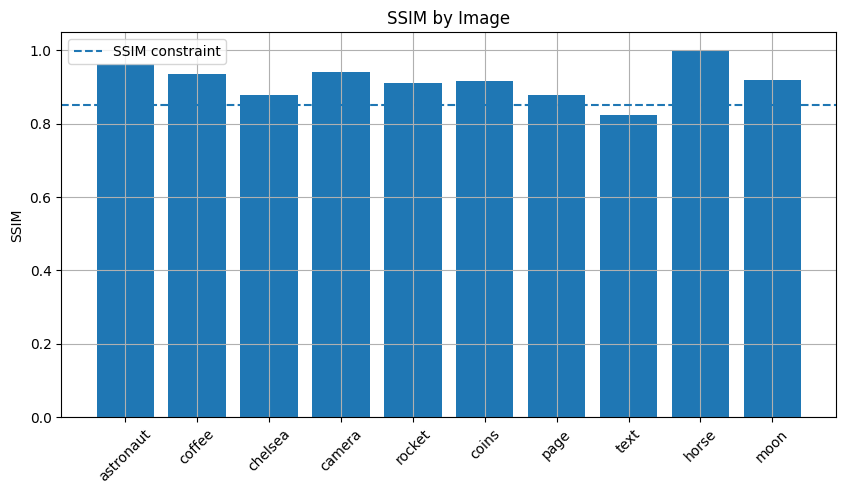


=== 計算コストの内訳 ===
Strategy: HAND_FI
Selected NN architecture: None
Compute cost: 14
Mean communication time [s]: 0.876
Mean compute time [s]: 0.028
Mean total time [s]: 0.904

=== 提出用まとめ ===
Team: Team A
Strategy: HAND_FI
Optimizer: NONE
Selected NN architecture: None
Score: 83.246
Mean SSIM: 0.917
Mean bits [kbit]: 43.777
Mean total time [s]: 0.904
Violation rate: 0.100

設計意図を文章で説明してください。
例：NNで必要チャネル数を直接予測し、過剰な送信を抑えながらSSIM制約を満たすことを狙った。


In [1]:
# ============================================================
# 第11〜13回 システム設計演習
# IoT画像伝送システム設計コンペ
#
# 学生が主に変更する場所：
# - 1. 設計パラメータ
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage import data, img_as_float
from skimage.transform import resize
from skimage.metrics import structural_similarity as ssim

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

np.random.seed(0)

# ============================================================
# 1. 【変更可能】学生が設計するパラメータ
# ============================================================

TEAM_NAME = "Team A"

# ------------------------------------------------------------
# システム構成を選択
# ------------------------------------------------------------
# CHANNEL_STRATEGY:
# "HAND_FI"     : HAND複雑度推定 + FIチャネル制御
# "HAND_RULE"   : HAND複雑度推定 + RULEチャネル制御
# "HAND_ANFIS"  : HAND複雑度推定 + ANFISチャネル制御
# "NN"          : NNで必要チャネル数を直接予測
# "NAS"         : NAS-likeで軽量NN構造を選び、必要チャネル数を直接予測
# "FIXED"       : 全画像で固定チャネル
CHANNEL_STRATEGY = "HAND_FI"

# OPTIMIZER:
# "NONE" : 手動設定を使う
# "GA"   : HAND_FIのFIパラメータをGAで探索
OPTIMIZER = "NONE"

# ------------------------------------------------------------
# 画質制約
# ------------------------------------------------------------
SSIM_CONSTRAINT = 0.85

# ------------------------------------------------------------
# FIXED / RULE / FI で用いる設計パラメータ
# ------------------------------------------------------------
FIXED_CHANNELS = 4

RULE_SIMPLE_TH = 0.35
RULE_COMPLEX_TH = 0.70

CHANNEL_SIMPLE = 2
CHANNEL_MEDIUM = 4
CHANNEL_COMPLEX = 8

FI_SIMPLE_CENTER = 0.20
FI_MEDIUM_CENTER = 0.50
FI_COMPLEX_CENTER = 0.80
FI_WIDTH = 0.22

# ------------------------------------------------------------
# NN / NAS-like 設定
# ------------------------------------------------------------
# NN方式で使う固定構造
NN_ARCHITECTURE = (16, 8)

# NAS-like方式で比較する候補構造
# 小さい構造ほど推論コストが小さいが、表現力不足の可能性がある
NAS_CANDIDATES = [
    (4,),
    (8,),
    (16,),
    (16, 8),
    (32, 16),
]

# NAS-likeでモデル規模をどの程度重視するか
# 大きくすると軽量NNが選ばれやすい
NAS_SIZE_PENALTY = 0.00002

# ------------------------------------------------------------
# ANFIS設定
# ------------------------------------------------------------
ANFIS_LR = 0.03
ANFIS_EPOCHS = 800
ANFIS_NUM_INPUTS = 1
ANFIS_NUM_MFS = 3

# ------------------------------------------------------------
# GA設定
# ------------------------------------------------------------
GA_POP_SIZE = 20
GA_GENERATIONS = 25
GA_MUTATION_RATE = 0.25
GA_MUTATION_SCALE = 0.08

# ------------------------------------------------------------
# スコア重み：全チーム共通で固定する想定
# ------------------------------------------------------------
W_SSIM = 100.0
W_BITS = 0.12
W_TOTAL_TIME = 0.20
W_VIOLATION = 30.0

# MCU処理時間を疑似的に秒へ変換する係数
COMPUTE_TIME_SCALE = 0.002

# 視覚表示する画像数
NUM_DISPLAY_IMAGES = 6


# ============================================================
# 2. 【変更不可】画像データ準備
# ============================================================

TARGET_SIZE = 128
MAX_CHANNELS = 8
MIN_CHANNELS = 1
BANDWIDTH_KBPS = 50.0


def to_rgb_float(img):
    img = img_as_float(img)
    if img.ndim == 2:
        img = np.stack([img, img, img], axis=-1)
    if img.shape[-1] == 4:
        img = img[:, :, :3]
    img = resize(img, (TARGET_SIZE, TARGET_SIZE), anti_aliasing=True)
    return np.clip(img, 0, 1)


# scikit-image内蔵画像を使用。インターネット不要。
image_list = [
    ("astronaut", to_rgb_float(data.astronaut())),
    ("coffee", to_rgb_float(data.coffee())),
    ("chelsea", to_rgb_float(data.chelsea())),
    ("camera", to_rgb_float(data.camera())),
    ("rocket", to_rgb_float(data.rocket())),
    ("coins", to_rgb_float(data.coins())),
    ("page", to_rgb_float(data.page())),
    ("text", to_rgb_float(data.text())),
    ("horse", to_rgb_float(data.horse())),
    ("moon", to_rgb_float(data.moon())),
]


# ============================================================
# 3. 【変更不可】画像特徴量とHAND複雑度
# ============================================================


def extract_features(img):
    gray = np.mean(img, axis=-1)

    edge_x = np.abs(np.diff(gray, axis=1)).mean()
    edge_y = np.abs(np.diff(gray, axis=0)).mean()
    edge = edge_x + edge_y

    contrast = gray.std()
    brightness = gray.mean()
    color_var = img.reshape(-1, 3).std(axis=0).mean()

    return np.array([edge, contrast, brightness, color_var])


features_raw = np.array([extract_features(img) for _, img in image_list])

# 特徴量を0〜1へ正規化
features = (features_raw - features_raw.min(axis=0)) / (features_raw.max(axis=0) - features_raw.min(axis=0) + 1e-9)

# HAND方式の複雑度：エッジとコントラストのみを用いる
hand_complexity_raw = 0.70 * features_raw[:, 0] + 0.30 * features_raw[:, 1]
hand_complexity = (hand_complexity_raw - hand_complexity_raw.min()) / (hand_complexity_raw.max() - hand_complexity_raw.min() + 1e-9)

# 基礎サイズ[kbit]：HAND複雑度が高いほど大きいと仮定
base_size_kbit = 30 + 70 * hand_complexity

image_df = pd.DataFrame({
    "image_id": np.arange(len(image_list)),
    "name": [name for name, _ in image_list],
    "hand_complexity": hand_complexity,
    "base_size_kbit": base_size_kbit,
    "edge": features[:, 0],
    "contrast": features[:, 1],
    "brightness": features[:, 2],
    "color_var": features[:, 3],
})

print("=== 使用画像一覧 ===")
display(image_df)


# ============================================================
# 4. 【変更不可】疑似伝送・復元画像生成
# ============================================================


def reconstruct_image(img, channels):
    """
    チャネル数に応じた疑似圧縮・復元。
    channel数が少ないほど、空間解像度と色階調が劣化する。
    """
    channels = int(np.clip(channels, MIN_CHANNELS, MAX_CHANNELS))
    ratio = channels / MAX_CHANNELS

    # 空間解像度を削減してから復元
    small_size = int(16 + ratio * (TARGET_SIZE - 16))
    small = resize(img, (small_size, small_size), anti_aliasing=True)
    recon = resize(small, (TARGET_SIZE, TARGET_SIZE), anti_aliasing=True)

    # 色階調を削減
    levels = int(8 + ratio * 248)
    recon = np.round(recon * (levels - 1)) / (levels - 1)

    return np.clip(recon, 0, 1)


def transmitted_bits(base_size, channels):
    return base_size * (channels / MAX_CHANNELS)


def communication_time(bits_kbit):
    return bits_kbit / BANDWIDTH_KBPS


# ============================================================
# 5. 【変更不可】Required Channels 教師データ生成
# ============================================================


def required_channels_for_image(img):
    """
    1〜8チャネルを順に試し、SSIM制約を満たす最小チャネル数を求める。
    これがNN / NAS-like の教師出力になる。
    """
    for ch in range(MIN_CHANNELS, MAX_CHANNELS + 1):
        recon = reconstruct_image(img, ch)
        ssim_val = ssim(img, recon, channel_axis=-1, data_range=1.0)
        if ssim_val >= SSIM_CONSTRAINT:
            return ch
    return MAX_CHANNELS


required_channels = np.array([required_channels_for_image(img) for _, img in image_list])
image_df["required_channels"] = required_channels

print("=== Required Channels 教師データ ===")
display(image_df[["name", "hand_complexity", "required_channels"]])


# ============================================================
# 6. 【変更不可】モデル規模・MCU計算コスト
# ============================================================


def nn_parameter_count(input_dim, hidden_layers, output_dim=1):
    layers = [input_dim] + list(hidden_layers) + [output_dim]
    count = 0
    for i in range(len(layers) - 1):
        count += layers[i] * layers[i + 1]
        count += layers[i + 1]
    return count


def nn_compute_cost(input_dim, hidden_layers, output_dim=1):
    return nn_parameter_count(input_dim, hidden_layers, output_dim)


def fi_rule_count(num_inputs=1, num_mfs=3):
    return num_mfs ** num_inputs


def fi_compute_cost(num_inputs=1, num_mfs=3):
    n_rules = fi_rule_count(num_inputs, num_mfs)
    return num_inputs * num_mfs + n_rules


def anfis_compute_cost(num_inputs=1, num_mfs=3):
    n_rules = fi_rule_count(num_inputs, num_mfs)
    return num_inputs * num_mfs + n_rules * (1 + num_inputs)


def get_compute_cost(strategy, selected_arch=None):
    """
    運用時のMCU計算コスト。
    NAS-likeは探索コストではなく、選択されたNN構造の推論コストで評価する。
    GAは設計時の最適化器なので、運用時コストには直接加えない。
    """
    if strategy == "FIXED":
        return 1
    if strategy == "HAND_RULE":
        return 8 + 2
    if strategy == "HAND_FI":
        return 8 + fi_compute_cost(num_inputs=1, num_mfs=3)
    if strategy == "HAND_ANFIS":
        return 8 + anfis_compute_cost(num_inputs=ANFIS_NUM_INPUTS, num_mfs=ANFIS_NUM_MFS)
    if strategy == "NN":
        return nn_compute_cost(input_dim=4, hidden_layers=NN_ARCHITECTURE)
    if strategy == "NAS":
        if selected_arch is None:
            selected_arch = NAS_CANDIDATES[0]
        return nn_compute_cost(input_dim=4, hidden_layers=selected_arch)
    raise ValueError("Unknown strategy")


def compute_time_per_image(strategy, selected_arch=None):
    return COMPUTE_TIME_SCALE * get_compute_cost(strategy, selected_arch)


# ============================================================
# 7. 【変更不可】HAND_RULE / HAND_FI / HAND_ANFIS
# ============================================================


def decide_channels_fixed(n):
    return np.full(n, FIXED_CHANNELS, dtype=int)


def decide_channels_rule(complexity):
    channels = np.zeros_like(complexity, dtype=int)
    channels[complexity < RULE_SIMPLE_TH] = CHANNEL_SIMPLE
    channels[(complexity >= RULE_SIMPLE_TH) & (complexity < RULE_COMPLEX_TH)] = CHANNEL_MEDIUM
    channels[complexity >= RULE_COMPLEX_TH] = CHANNEL_COMPLEX
    return np.clip(channels, MIN_CHANNELS, MAX_CHANNELS)


def gaussian_mf(x, c, w):
    return np.exp(-0.5 * ((x - c) / w) ** 2)


def decide_channels_fi(complexity,
                       simple_center=FI_SIMPLE_CENTER,
                       medium_center=FI_MEDIUM_CENTER,
                       complex_center=FI_COMPLEX_CENTER,
                       width=FI_WIDTH,
                       ch_simple=CHANNEL_SIMPLE,
                       ch_medium=CHANNEL_MEDIUM,
                       ch_complex=CHANNEL_COMPLEX):
    mu_simple = gaussian_mf(complexity, simple_center, width)
    mu_medium = gaussian_mf(complexity, medium_center, width)
    mu_complex = gaussian_mf(complexity, complex_center, width)

    numerator = mu_simple * ch_simple + mu_medium * ch_medium + mu_complex * ch_complex
    denominator = mu_simple + mu_medium + mu_complex + 1e-9

    channels_cont = numerator / denominator
    channels = np.rint(channels_cont).astype(int)
    return np.clip(channels, MIN_CHANNELS, MAX_CHANNELS)


class SimpleANFIS1D:
    """
    1入力1出力の簡易ANFIS。
    入力：HAND複雑度
    出力：必要チャネル数
    3つのガウスMFとSugeno後件部 f_i = p_i x + r_i を学習する。
    """
    def __init__(self):
        self.c = np.array([0.20, 0.50, 0.80], dtype=float)
        self.s = np.array([0.22, 0.22, 0.22], dtype=float)
        self.p = np.array([0.0, 0.0, 0.0], dtype=float)
        self.r = np.array([CHANNEL_SIMPLE, CHANNEL_MEDIUM, CHANNEL_COMPLEX], dtype=float)

    def predict_continuous(self, x):
        x = np.asarray(x)
        mu = np.stack([gaussian_mf(x, self.c[i], abs(self.s[i]) + 1e-6) for i in range(3)], axis=1)
        w = mu / (mu.sum(axis=1, keepdims=True) + 1e-9)
        f = np.stack([self.p[i] * x + self.r[i] for i in range(3)], axis=1)
        y = (w * f).sum(axis=1)
        return y

    def predict_channels(self, x):
        y = self.predict_continuous(x)
        return np.clip(np.rint(y).astype(int), MIN_CHANNELS, MAX_CHANNELS)

    def fit(self, x, y_target, lr=0.03, epochs=800):
        x = np.asarray(x)
        y_target = np.asarray(y_target)

        for _ in range(epochs):
            mu = np.stack([gaussian_mf(x, self.c[i], abs(self.s[i]) + 1e-6) for i in range(3)], axis=1)
            w = mu / (mu.sum(axis=1, keepdims=True) + 1e-9)
            f = np.stack([self.p[i] * x + self.r[i] for i in range(3)], axis=1)
            y = (w * f).sum(axis=1)
            err = y - y_target

            grad_p = np.array([np.mean(2 * err * w[:, i] * x) for i in range(3)])
            grad_r = np.array([np.mean(2 * err * w[:, i]) for i in range(3)])

            self.p -= lr * grad_p
            self.r -= lr * grad_r

            self.r = np.clip(self.r, MIN_CHANNELS, MAX_CHANNELS)
            self.p = np.clip(self.p, -5, 5)


def decide_channels_anfis(complexity):
    model = SimpleANFIS1D()
    model.fit(complexity, required_channels, lr=ANFIS_LR, epochs=ANFIS_EPOCHS)

    print("=== ANFIS learned consequent parameters ===")
    print("p:", model.p)
    print("r:", model.r)

    return model.predict_channels(complexity)


# ============================================================
# 8. 【変更不可】NN / NAS-like 必要チャネル数予測
# ============================================================


def make_synthetic_required_channel_data(n=600, seed=0):
    """
    NN学習用の疑似データを生成する。
    入力：画像特徴量 edge, contrast, brightness, color_var
    教師：SSIM制約を満たすために必要なチャネル数に相当する値

    ここでは演習用に疑似教師を作るが、実システムでは
    実際に圧縮・復元してSSIMを測定し、必要チャネル数を教師にする。
    """
    rng = np.random.default_rng(seed)
    X = rng.uniform(0, 1, size=(n, 4))

    # 「必要チャネル数」を模擬する教師関数。
    # edge/contrastが高いほど必要チャネル数が増える。
    # brightnessやcolor_varも少し影響する。
    required = (
        1.5
        + 4.5 * X[:, 0]
        + 1.6 * X[:, 1]
        + 0.6 * X[:, 3]
        + 0.8 * np.sin(np.pi * X[:, 0]) * X[:, 1]
    )
    required += rng.normal(0, 0.30, size=n)
    required = np.clip(required, MIN_CHANNELS, MAX_CHANNELS)
    return X, required


def train_required_channel_nn(hidden_layer_sizes=(16, 8), seed=0):
    X_train, y_train = make_synthetic_required_channel_data(seed=seed)
    model = make_pipeline(
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=hidden_layer_sizes,
            activation="tanh",
            max_iter=2000,
            random_state=seed,
            learning_rate_init=0.01
        )
    )
    model.fit(X_train, y_train)
    return model


def decide_channels_nn():
    model = train_required_channel_nn(hidden_layer_sizes=NN_ARCHITECTURE, seed=0)
    pred = model.predict(features)
    channels = np.clip(np.rint(pred).astype(int), MIN_CHANNELS, MAX_CHANNELS)
    return channels, NN_ARCHITECTURE


def decide_channels_nas_like():
    """
    簡易NAS-like：候補NN構造を複数試し、
    検証誤差とモデル規模の両方を考慮して構造を選ぶ。
    """
    X_train, y_train = make_synthetic_required_channel_data(n=700, seed=1)
    X_val, y_val = make_synthetic_required_channel_data(n=250, seed=2)

    records = []
    best_model = None
    best_objective = np.inf
    best_arch = None

    for arch in NAS_CANDIDATES:
        model = make_pipeline(
            StandardScaler(),
            MLPRegressor(
                hidden_layer_sizes=arch,
                activation="tanh",
                max_iter=2000,
                random_state=0,
                learning_rate_init=0.01
            )
        )
        model.fit(X_train, y_train)
        pred = model.predict(X_val)
        mse = np.mean((pred - y_val) ** 2)
        params = nn_parameter_count(input_dim=4, hidden_layers=arch)

        # NAS-likeでは性能だけでなく軽量性も評価する
        objective = mse + NAS_SIZE_PENALTY * params

        records.append({
            "architecture": str(arch),
            "val_mse": mse,
            "params": params,
            "nas_objective": objective
        })

        if objective < best_objective:
            best_objective = objective
            best_model = model
            best_arch = arch

    print("=== NAS-like 構造探索結果 ===")
    display(pd.DataFrame(records))
    print(f"Selected architecture: {best_arch}")

    pred = best_model.predict(features)
    channels = np.clip(np.rint(pred).astype(int), MIN_CHANNELS, MAX_CHANNELS)
    return channels, best_arch


# ============================================================
# 9. 【変更不可】評価関数
# ============================================================


def evaluate_channels(channels, selected_arch=None):
    rows = []
    reconstructed_images = []

    compute_time = compute_time_per_image(CHANNEL_STRATEGY, selected_arch)
    compute_cost = get_compute_cost(CHANNEL_STRATEGY, selected_arch)

    for i, ((name, img), ch) in enumerate(zip(image_list, channels)):
        recon = reconstruct_image(img, ch)
        reconstructed_images.append(recon)

        ssim_val = ssim(img, recon, channel_axis=-1, data_range=1.0)
        bits = transmitted_bits(image_df.loc[i, "base_size_kbit"], ch)
        t_comm = communication_time(bits)
        t_total = t_comm + compute_time

        rows.append({
            "image_id": i,
            "name": name,
            "hand_complexity": image_df.loc[i, "hand_complexity"],
            "required_channels": image_df.loc[i, "required_channels"],
            "predicted_channels": int(ch),
            "ssim": ssim_val,
            "bits_kbit": bits,
            "communication_time_sec": t_comm,
            "compute_time_sec": compute_time,
            "total_time_sec": t_total,
            "compute_cost": compute_cost,
            "violation": ssim_val < SSIM_CONSTRAINT
        })

    result_df = pd.DataFrame(rows)

    mean_ssim = result_df["ssim"].mean()
    mean_bits = result_df["bits_kbit"].mean()
    mean_comm_time = result_df["communication_time_sec"].mean()
    mean_compute_time = result_df["compute_time_sec"].mean()
    mean_total_time = result_df["total_time_sec"].mean()
    violation_rate = result_df["violation"].mean()

    score = (
        W_SSIM * mean_ssim
        - W_BITS * mean_bits
        - W_TOTAL_TIME * mean_total_time
        - W_VIOLATION * violation_rate
    )

    summary = {
        "team": TEAM_NAME,
        "strategy": CHANNEL_STRATEGY,
        "optimizer": OPTIMIZER,
        "selected_nn_arch": str(selected_arch),
        "compute_cost": compute_cost,
        "score": score,
        "mean_ssim": mean_ssim,
        "mean_bits_kbit": mean_bits,
        "mean_comm_time_sec": mean_comm_time,
        "mean_compute_time_sec": mean_compute_time,
        "mean_total_time_sec": mean_total_time,
        "violation_rate": violation_rate,
        "min_ssim": result_df["ssim"].min(),
        "max_bits_kbit": result_df["bits_kbit"].max()
    }

    return summary, result_df, reconstructed_images


# ============================================================
# 10. 【変更不可】GAによるFIパラメータ探索
# ============================================================


def decode_individual(ind):
    simple_center = ind[0]
    medium_center = ind[1]
    complex_center = ind[2]
    width = ind[3]
    ch_simple = int(np.rint(ind[4]))
    ch_medium = int(np.rint(ind[5]))
    ch_complex = int(np.rint(ind[6]))
    return simple_center, medium_center, complex_center, width, ch_simple, ch_medium, ch_complex


def create_individual():
    return np.array([
        np.random.uniform(0.05, 0.35),
        np.random.uniform(0.35, 0.65),
        np.random.uniform(0.65, 0.95),
        np.random.uniform(0.12, 0.35),
        np.random.uniform(1, 4),
        np.random.uniform(3, 6),
        np.random.uniform(5, 8),
    ])


def repair_individual(ind):
    ind[0] = np.clip(ind[0], 0.05, 0.35)
    ind[1] = np.clip(ind[1], 0.35, 0.65)
    ind[2] = np.clip(ind[2], 0.65, 0.95)
    ind[3] = np.clip(ind[3], 0.12, 0.35)
    ind[4] = np.clip(ind[4], 1, 4)
    ind[5] = np.clip(ind[5], 3, 6)
    ind[6] = np.clip(ind[6], 5, 8)
    return ind


def evaluate_individual(ind):
    params = decode_individual(ind)
    channels = decide_channels_fi(hand_complexity, *params)
    summary, _, _ = evaluate_channels(channels, selected_arch=None)
    return summary["score"]


def roulette_selection(population, scores):
    shifted = scores - np.min(scores) + 1e-6
    probs = shifted / np.sum(shifted)
    idx = np.random.choice(len(population), p=probs)
    return population[idx].copy()


def run_ga():
    population = np.array([create_individual() for _ in range(GA_POP_SIZE)])
    history = []
    best_ind = None
    best_score = -np.inf

    for gen in range(GA_GENERATIONS):
        scores = np.array([evaluate_individual(ind) for ind in population])
        gen_best_idx = np.argmax(scores)

        if scores[gen_best_idx] > best_score:
            best_score = scores[gen_best_idx]
            best_ind = population[gen_best_idx].copy()

        history.append({
            "generation": gen,
            "best_score": np.max(scores),
            "mean_score": np.mean(scores)
        })

        new_population = [population[gen_best_idx].copy()]

        while len(new_population) < GA_POP_SIZE:
            p1 = roulette_selection(population, scores)
            p2 = roulette_selection(population, scores)

            alpha = np.random.rand()
            c1 = alpha * p1 + (1 - alpha) * p2
            c2 = alpha * p2 + (1 - alpha) * p1

            if np.random.rand() < GA_MUTATION_RATE:
                c1 += np.random.normal(0, GA_MUTATION_SCALE, size=len(c1))
            if np.random.rand() < GA_MUTATION_RATE:
                c2 += np.random.normal(0, GA_MUTATION_SCALE, size=len(c2))

            new_population.append(repair_individual(c1))
            if len(new_population) < GA_POP_SIZE:
                new_population.append(repair_individual(c2))

        population = np.array(new_population)

    return best_ind, pd.DataFrame(history)


# ============================================================
# 11. 実行
# ============================================================

selected_arch = None

if CHANNEL_STRATEGY == "FIXED":
    channels = decide_channels_fixed(len(image_list))
    ga_history = None

elif CHANNEL_STRATEGY == "HAND_RULE":
    channels = decide_channels_rule(hand_complexity)
    ga_history = None

elif CHANNEL_STRATEGY == "HAND_FI":
    if OPTIMIZER == "GA":
        best_ind, ga_history = run_ga()
        print("=== GA best parameters ===")
        print("simple_center, medium_center, complex_center, width, ch_simple, ch_medium, ch_complex")
        print(decode_individual(best_ind))
        channels = decide_channels_fi(hand_complexity, *decode_individual(best_ind))
    else:
        ga_history = None
        channels = decide_channels_fi(hand_complexity)

elif CHANNEL_STRATEGY == "HAND_ANFIS":
    channels = decide_channels_anfis(hand_complexity)
    ga_history = None

elif CHANNEL_STRATEGY == "NN":
    channels, selected_arch = decide_channels_nn()
    ga_history = None

elif CHANNEL_STRATEGY == "NAS":
    channels, selected_arch = decide_channels_nas_like()
    ga_history = None

else:
    raise ValueError("Unknown CHANNEL_STRATEGY")

summary, result_df, reconstructed_images = evaluate_channels(channels, selected_arch=selected_arch)

print("\n=== コンペ結果 ===")
display(pd.DataFrame([summary]))

print("\n=== 画像ごとの評価結果 ===")
display(result_df)


# ============================================================
# 12. 視覚的品質評価
# ============================================================


def show_visual_comparison(indices=None):
    if indices is None:
        sorted_idx = np.argsort(result_df["hand_complexity"].values)
        indices = list(sorted_idx[:2]) + list(sorted_idx[len(sorted_idx)//2:len(sorted_idx)//2+2]) + list(sorted_idx[-2:])
        indices = indices[:NUM_DISPLAY_IMAGES]

    for idx in indices:
        name, original = image_list[idx]
        recon = reconstructed_images[idx]
        diff = np.abs(original - recon)

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))

        axes[0].imshow(original)
        axes[0].set_title(f"Original\n{name}")
        axes[0].axis("off")

        axes[1].imshow(recon)
        axes[1].set_title(
            f"Reconstructed\nch={result_df.loc[idx, 'predicted_channels']}, SSIM={result_df.loc[idx, 'ssim']:.3f}"
        )
        axes[1].axis("off")

        axes[2].imshow(np.clip(diff * 4, 0, 1))
        axes[2].set_title("Difference x4")
        axes[2].axis("off")

        plt.suptitle(
            f"required ch={result_df.loc[idx, 'required_channels']}, "
            f"selected ch={result_df.loc[idx, 'predicted_channels']}, "
            f"bits={result_df.loc[idx, 'bits_kbit']:.1f} kbit, "
            f"total time={result_df.loc[idx, 'total_time_sec']:.2f} s"
        )
        plt.tight_layout()
        plt.show()


show_visual_comparison()


# ============================================================
# 13. 設計結果の可視化
# ============================================================

plt.figure(figsize=(10, 5))
plt.scatter(result_df["hand_complexity"], result_df["required_channels"], s=90, label="Required channels")
plt.scatter(result_df["hand_complexity"], result_df["predicted_channels"], s=90, marker="x", label="Selected channels")
plt.xlabel("HAND complexity")
plt.ylabel("Channels")
plt.title("Required Channels vs Selected Channels")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(result_df["hand_complexity"], result_df["ssim"], s=80)
plt.axhline(SSIM_CONSTRAINT, linestyle="--", label="SSIM constraint")
plt.xlabel("HAND complexity")
plt.ylabel("SSIM")
plt.title("Complexity vs SSIM")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(result_df["bits_kbit"], result_df["ssim"], s=80)
plt.axhline(SSIM_CONSTRAINT, linestyle="--", label="SSIM constraint")
plt.xlabel("Transmitted bits [kbit]")
plt.ylabel("SSIM")
plt.title("Trade-off: Transmission vs Quality")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(result_df["total_time_sec"], result_df["ssim"], s=80)
plt.axhline(SSIM_CONSTRAINT, linestyle="--", label="SSIM constraint")
plt.xlabel("Total time = communication + compute [s]")
plt.ylabel("SSIM")
plt.title("Trade-off: Total Time vs Quality")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(result_df["name"], result_df["ssim"])
plt.axhline(SSIM_CONSTRAINT, linestyle="--", label="SSIM constraint")
plt.xticks(rotation=45)
plt.ylabel("SSIM")
plt.title("SSIM by Image")
plt.legend()
plt.grid(True)
plt.show()

if ga_history is not None:
    plt.figure(figsize=(10, 5))
    plt.plot(ga_history["generation"], ga_history["best_score"], label="Best score")
    plt.plot(ga_history["generation"], ga_history["mean_score"], label="Mean score")
    plt.xlabel("Generation")
    plt.ylabel("Score")
    plt.title("GA Optimization Process")
    plt.legend()
    plt.grid(True)
    plt.show()


# ============================================================
# 14. 計算コスト説明
# ============================================================

print("\n=== 計算コストの内訳 ===")
print(f"Strategy: {CHANNEL_STRATEGY}")
print(f"Selected NN architecture: {selected_arch}")
print(f"Compute cost: {summary['compute_cost']}")
print(f"Mean communication time [s]: {summary['mean_comm_time_sec']:.3f}")
print(f"Mean compute time [s]: {summary['mean_compute_time_sec']:.3f}")
print(f"Mean total time [s]: {summary['mean_total_time_sec']:.3f}")


# ============================================================
# 15. 提出用まとめ
# ============================================================

print("\n=== 提出用まとめ ===")
print(f"Team: {TEAM_NAME}")
print(f"Strategy: {CHANNEL_STRATEGY}")
print(f"Optimizer: {OPTIMIZER}")
print(f"Selected NN architecture: {selected_arch}")
print(f"Score: {summary['score']:.3f}")
print(f"Mean SSIM: {summary['mean_ssim']:.3f}")
print(f"Mean bits [kbit]: {summary['mean_bits_kbit']:.3f}")
print(f"Mean total time [s]: {summary['mean_total_time_sec']:.3f}")
print(f"Violation rate: {summary['violation_rate']:.3f}")

print("\n設計意図を文章で説明してください。")
print("例：NNで必要チャネル数を直接予測し、過剰な送信を抑えながらSSIM制約を満たすことを狙った。")


# ============================================================
# 16. 考察用メモ欄
# ============================================================

# 以下をグループで議論してください。
# 1. なぜそのCHANNEL_STRATEGYを選んだか。
# 2. Required Channels と Selected Channels は近かったか。
# 3. どの画像でSSIM制約を破ったか。それはなぜか。
# 4. 通信時間と計算時間のどちらが支配的だったか。
# 5. NAS-likeで選ばれたNN構造は軽量だったか、高性能寄りだったか。
# 6. 見た目とSSIMは一致していたか。
# 7. 通信量削減と画質維持のトレードオフをどう考えたか。
# 8. 次に改善するなら、どのサブシステムを変更するか。
